# 🚦 Traffic Sign Recognition using CNN + Transformer

This notebook implements a **hybrid ConvNeXt + Transformer** model for traffic sign classification using the GTSRB dataset.

## Key Features:
- **Architecture**: ConvNeXt backbone + Transformer encoder
- **Augmentation**: Weather effects, motion blur, occlusion
- **Training**: Mixed-precision, class-balanced sampling
- **Evaluation**: Per-class metrics, confusion matrix, calibration

---

## 1. Setup & Imports

In [1]:
# Install dependencies (run once)
# !pip install torch torchvision timm albumentations pandas numpy scikit-learn matplotlib seaborn tqdm

In [2]:
import os
import sys
import random
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as T
import torchvision.transforms.functional as TF
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 PyTorch Version: {torch.__version__}")
print(f"🖥️ Device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🔧 PyTorch Version: 2.9.1+cpu
🖥️ Device: cpu


## 2. Configuration

In [3]:
# Configuration
CONFIG = {
    # Dataset
    'data_path': r'C:\Users\ASUS\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1',
    'num_classes': 43,
    'image_size': 224,
    'val_split': 0.2,
    
    # Model
    'backbone': 'resnet34',  # Use 'convnext_tiny' for best results (slower)
    'pretrained': True,
    'transformer_layers': 2,
    'transformer_heads': 8,
    'transformer_dim': 384,
    'dropout': 0.2,
    
    # Training
    'batch_size': 32,
    'epochs': 30,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'warmup_epochs': 3,
    'use_amp': True and torch.cuda.is_available(),
    
    # Loss
    'label_smoothing': 0.1,
    'focal_gamma': 2.0,
    
    # Paths
    'models_dir': 'models',
    'outputs_dir': 'outputs',
}

# Create directories
Path(CONFIG['models_dir']).mkdir(exist_ok=True)
Path(CONFIG['outputs_dir']).mkdir(exist_ok=True)

print("✅ Configuration loaded")
print(f"   Image size: {CONFIG['image_size']}")
print(f"   Backbone: {CONFIG['backbone']}")
print(f"   Epochs: {CONFIG['epochs']}")

✅ Configuration loaded
   Image size: 224
   Backbone: resnet34
   Epochs: 30


## 3. Traffic Sign Class Names

In [4]:
# GTSRB Traffic Sign Class Names
GTSRB_CLASSES = [
    "Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)",
    "Speed limit (60km/h)", "Speed limit (70km/h)", "Speed limit (80km/h)",
    "End of speed limit (80km/h)", "Speed limit (100km/h)", "Speed limit (120km/h)",
    "No passing", "No passing for vehicles over 3.5t",
    "Right-of-way at intersection", "Priority road", "Yield",
    "Stop", "No vehicles", "Vehicles over 3.5t prohibited",
    "No entry", "General caution", "Dangerous curve left",
    "Dangerous curve right", "Double curve", "Bumpy road",
    "Slippery road", "Road narrows on right", "Road work",
    "Traffic signals", "Pedestrians", "Children crossing",
    "Bicycles crossing", "Beware of ice/snow", "Wild animals crossing",
    "End all speed and passing limits", "Turn right ahead",
    "Turn left ahead", "Ahead only", "Go straight or right",
    "Go straight or left", "Keep right", "Keep left",
    "Roundabout mandatory", "End of no passing",
    "End of no passing by vehicles over 3.5t"
]

print(f"📋 Total classes: {len(GTSRB_CLASSES)}")

📋 Total classes: 43


## 4. Data Loading & Exploration

In [5]:
# Load CSV files
data_path = Path(CONFIG['data_path'])

train_df = pd.read_csv(data_path / 'Train.csv')
test_df = pd.read_csv(data_path / 'Test.csv')

print(f"📊 Training samples: {len(train_df):,}")
print(f"📊 Test samples: {len(test_df):,}")
print(f"\n📋 Columns: {train_df.columns.tolist()}")

📊 Training samples: 39,209
📊 Test samples: 12,630

📋 Columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']


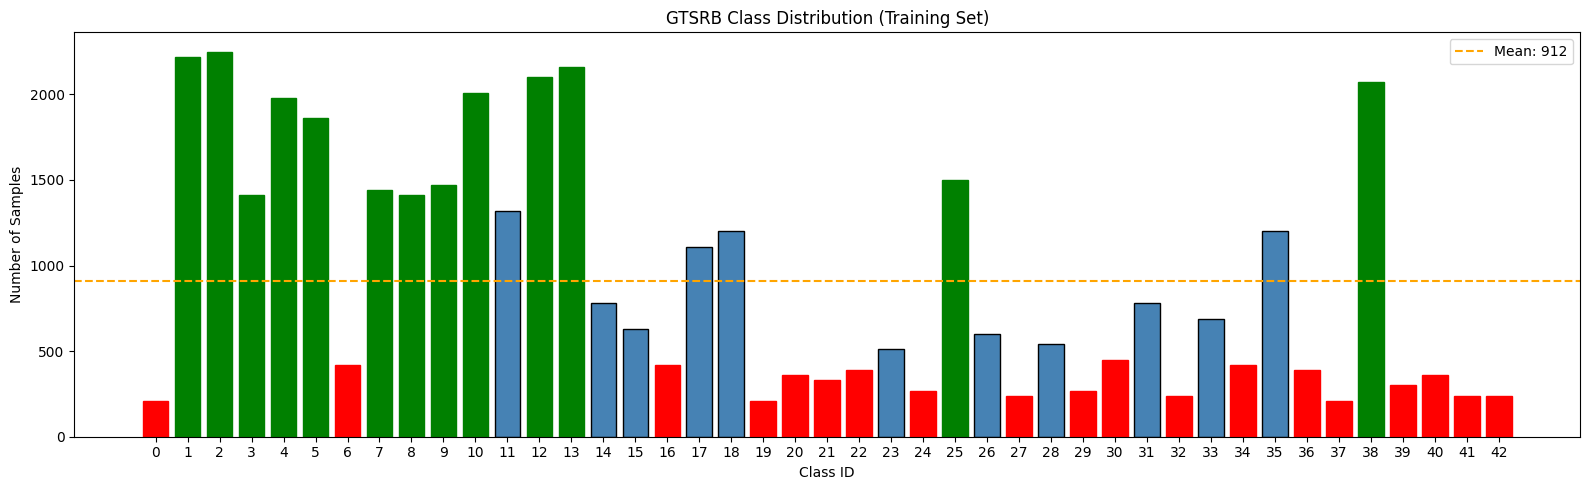


📈 Class count statistics:
   Min: 210 (Class 0)
   Max: 2250 (Class 2)
   Imbalance ratio: 10.7x


In [6]:
# Class distribution
class_counts = train_df['ClassId'].value_counts().sort_index()

plt.figure(figsize=(16, 5))
bars = plt.bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Class ID')
plt.ylabel('Number of Samples')
plt.title('GTSRB Class Distribution (Training Set)')
plt.xticks(range(43))

# Highlight imbalanced classes
mean_count = class_counts.mean()
for i, bar in enumerate(bars):
    if class_counts.iloc[i] < mean_count * 0.5:
        bar.set_color('red')
    elif class_counts.iloc[i] > mean_count * 1.5:
        bar.set_color('green')

plt.axhline(y=mean_count, color='orange', linestyle='--', label=f'Mean: {mean_count:.0f}')
plt.legend()
plt.tight_layout()
plt.savefig(Path(CONFIG['outputs_dir']) / 'class_distribution.png', dpi=150)
plt.show()

print(f"\n📈 Class count statistics:")
print(f"   Min: {class_counts.min()} (Class {class_counts.idxmin()})")
print(f"   Max: {class_counts.max()} (Class {class_counts.idxmax()})")
print(f"   Imbalance ratio: {class_counts.max() / class_counts.min():.1f}x")

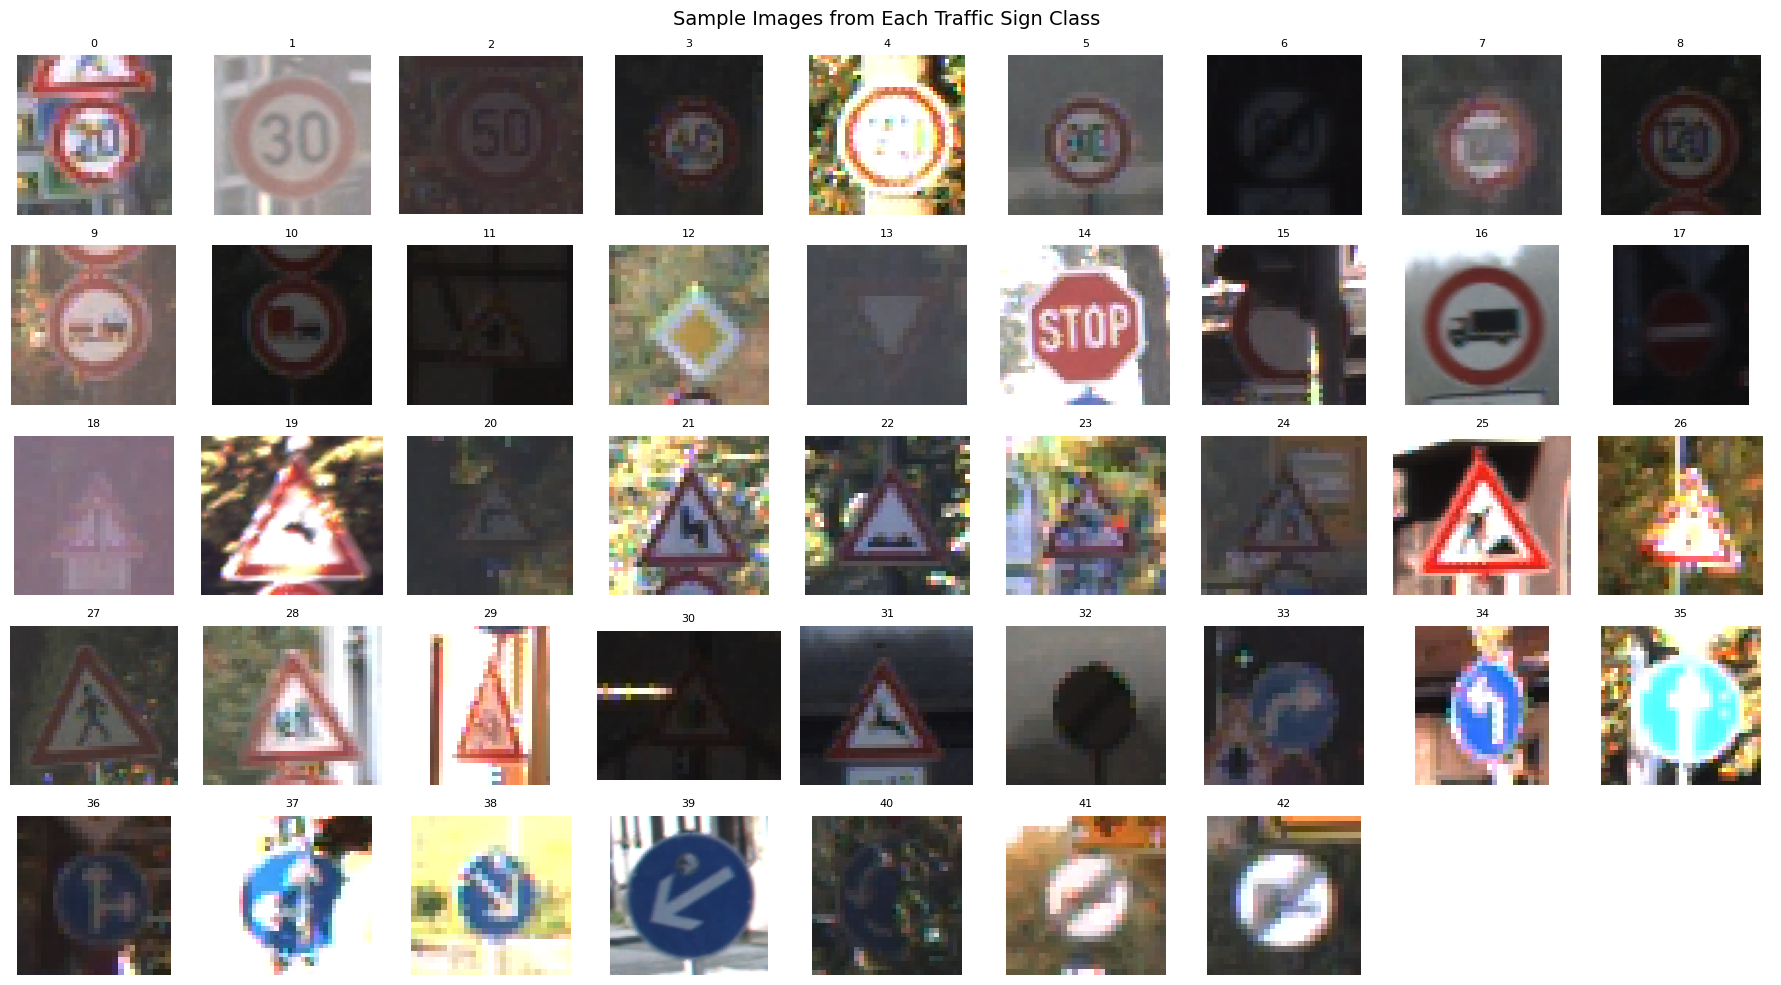

In [7]:
# Visualize sample images from each class
fig, axes = plt.subplots(5, 9, figsize=(18, 10))
axes = axes.flatten()

for class_id in range(min(43, 45)):
    if class_id >= 43:
        axes[class_id].axis('off')
        continue
    
    sample = train_df[train_df['ClassId'] == class_id].iloc[0]
    img_path = data_path / sample['Path']
    img = Image.open(img_path)
    
    axes[class_id].imshow(img)
    axes[class_id].set_title(f'{class_id}', fontsize=8)
    axes[class_id].axis('off')

# Hide extra axes
for i in range(43, len(axes)):
    axes[i].axis('off')

plt.suptitle('Sample Images from Each Traffic Sign Class', fontsize=14)
plt.tight_layout()
plt.savefig(Path(CONFIG['outputs_dir']) / 'sample_images.png', dpi=150)
plt.show()

## 5. Data Augmentation & Dataset

In [8]:
# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transforms
train_transform = T.Compose([
    T.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.15)),  # Occlusion simulation
])

# Validation transforms
val_transform = T.Compose([
    T.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("✅ Transforms defined")

✅ Transforms defined


In [9]:
class GTSRBDataset(Dataset):
    """GTSRB Dataset for Traffic Sign Recognition."""
    
    def __init__(self, df, data_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.transform = transform
        
        # Compute class weights
        class_counts = Counter(self.df['ClassId'])
        total = len(self.df)
        self.class_weights = torch.tensor([
            total / (CONFIG['num_classes'] * class_counts.get(i, 1))
            for i in range(CONFIG['num_classes'])
        ], dtype=torch.float32)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.data_dir / row['Path']
        image = Image.open(img_path).convert('RGB')
        label = int(row['ClassId'])
        
        if self.transform:
            image = self.transform(image)
        
        return image, label
    
    def get_sample_weights(self):
        """Get per-sample weights for WeightedRandomSampler."""
        return [self.class_weights[label].item() for label in self.df['ClassId']]

print("✅ Dataset class defined")

✅ Dataset class defined


In [10]:
# Create train/val split
train_indices, val_indices = train_test_split(
    np.arange(len(train_df)),
    test_size=CONFIG['val_split'],
    stratify=train_df['ClassId'],
    random_state=SEED
)

train_split_df = train_df.iloc[train_indices]
val_split_df = train_df.iloc[val_indices]

# Create datasets
train_dataset = GTSRBDataset(train_split_df, data_path, train_transform)
val_dataset = GTSRBDataset(val_split_df, data_path, val_transform)
test_dataset = GTSRBDataset(test_df, data_path, val_transform)

# Weighted sampler for class balancing
sample_weights = train_dataset.get_sample_weights()
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

print(f"📦 Training batches: {len(train_loader)}")
print(f"📦 Validation batches: {len(val_loader)}")
print(f"📦 Test batches: {len(test_loader)}")

📦 Training batches: 981
📦 Validation batches: 246
📦 Test batches: 395


## 6. Model Architecture

In [11]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation attention block."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class TransformerEncoder(nn.Module):
    """Simple Transformer encoder."""
    def __init__(self, d_model=384, nhead=8, num_layers=2, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
    
    def forward(self, x):
        return self.norm(self.encoder(x))


class TrafficSignModel(nn.Module):
    """Hybrid CNN + Transformer model for traffic sign recognition."""
    
    def __init__(self, num_classes=43, backbone='resnet34', pretrained=True,
                 transformer_layers=2, transformer_dim=384, dropout=0.2):
        super().__init__()
        
        # CNN Backbone
        self.backbone = timm.create_model(backbone, pretrained=pretrained, num_classes=0, global_pool='')
        
        # Get backbone output channels
        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224)
            out = self.backbone(dummy)
            if len(out.shape) == 4:
                self.backbone_channels = out.shape[1]
                self.feature_size = out.shape[2]
            else:
                self.backbone_channels = out.shape[-1]
                self.feature_size = int(out.shape[1] ** 0.5)
        
        # Attention
        self.attention = SEBlock(self.backbone_channels)
        
        # Project to transformer dimension
        self.proj = nn.Sequential(
            nn.Conv2d(self.backbone_channels, transformer_dim, 1),
            nn.BatchNorm2d(transformer_dim),
            nn.GELU()
        )
        
        # Transformer
        num_patches = self.feature_size ** 2
        self.cls_token = nn.Parameter(torch.randn(1, 1, transformer_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, transformer_dim) * 0.02)
        self.transformer = TransformerEncoder(d_model=transformer_dim, num_layers=transformer_layers, dropout=dropout)
        
        # Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(transformer_dim),
            nn.Dropout(dropout),
            nn.Linear(transformer_dim, transformer_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(transformer_dim, num_classes)
        )
    
    def forward(self, x):
        B = x.shape[0]
        
        # Backbone
        features = self.backbone(x)
        if len(features.shape) == 3:
            H = W = int(features.shape[1] ** 0.5)
            features = features.permute(0, 2, 1).reshape(B, -1, H, W)
        
        # Attention + projection
        features = self.attention(features)
        features = self.proj(features)
        
        # Flatten and add CLS token
        features = features.flatten(2).permute(0, 2, 1)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        features = torch.cat([cls_tokens, features], dim=1)
        features = features + self.pos_embed
        
        # Transformer
        features = self.transformer(features)
        
        # Classification
        return self.head(features[:, 0])

print("✅ Model classes defined")

✅ Model classes defined


In [12]:
# Create model
model = TrafficSignModel(
    num_classes=CONFIG['num_classes'],
    backbone=CONFIG['backbone'],
    pretrained=CONFIG['pretrained'],
    transformer_layers=CONFIG['transformer_layers'],
    transformer_dim=CONFIG['transformer_dim'],
    dropout=CONFIG['dropout']
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🧠 Model: {CONFIG['backbone']} + Transformer")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# Test forward pass
with torch.no_grad():
    test_input = torch.randn(2, 3, 224, 224).to(device)
    test_output = model(test_input)
    print(f"   Output shape: {test_output.shape}")

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

🧠 Model: resnet34 + Transformer
   Total parameters: 25,249,643
   Trainable parameters: 25,249,643
   Output shape: torch.Size([2, 43])


## 7. Loss Function

In [13]:
class FocalLoss(nn.Module):
    """Focal Loss for class imbalance."""
    def __init__(self, alpha=None, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, 
                                   label_smoothing=self.smoothing, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# Create loss with class weights
class_weights = train_dataset.class_weights.to(device)
criterion = FocalLoss(alpha=class_weights, gamma=CONFIG['focal_gamma'], smoothing=CONFIG['label_smoothing'])

print("✅ Focal Loss with class weights and label smoothing")

✅ Focal Loss with class weights and label smoothing


## 8. Training Loop

In [14]:
# Optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
scaler = GradScaler() if CONFIG['use_amp'] else None

# Training history
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []}
best_val_acc = 0.0

print(f"📚 Training for {CONFIG['epochs']} epochs...")
print(f"   Optimizer: AdamW (lr={CONFIG['learning_rate']})")
print(f"   Scheduler: CosineAnnealingWarmRestarts")
print(f"   AMP: {CONFIG['use_amp']}")

📚 Training for 30 epochs...
   Optimizer: AdamW (lr=0.0001)
   Scheduler: CosineAnnealingWarmRestarts
   AMP: False


In [15]:
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        if scaler:
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    for images, labels in tqdm(loader, desc='Validating'):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1

print("✅ Training functions defined")

✅ Training functions defined


In [ ]:
# Main training loop
print("\n" + "="*60)
print("🚀 STARTING TRAINING")
print("="*60 + "\n")

for epoch in range(CONFIG['epochs']):
    print(f"\n📅 Epoch {epoch+1}/{CONFIG['epochs']}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
    
    # Validate
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'config': CONFIG
        }, Path(CONFIG['models_dir']) / 'best_model.pth')
        print(f"   💾 New best model saved! Val Acc: {val_acc:.4f}")
    
    # Print metrics
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
    print(f"   LR: {current_lr:.2e} | Best Val Acc: {best_val_acc:.4f}")

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print(f"   Best Validation Accuracy: {best_val_acc:.4f}")
print("="*60)


🚀 STARTING TRAINING


📅 Epoch 1/30


Training:   0%|          | 0/981 [00:00<?, ?it/s]

Validating:   0%|          | 0/246 [00:00<?, ?it/s]

   💾 New best model saved! Val Acc: 0.8372
   Train Loss: 2.5570 | Train Acc: 0.5477
   Val Loss: 0.8042 | Val Acc: 0.8372 | Val F1: 0.8762
   LR: 9.76e-05 | Best Val Acc: 0.8372

📅 Epoch 2/30


Training:   0%|          | 0/981 [00:00<?, ?it/s]

...

   💾 New best model saved! Val Acc: 0.9489
   Train Loss: 0.8518 | Train Acc: 0.9117
   Val Loss: 0.6102 | Val Acc: 0.9489 | Val F1: 0.9646
   LR: 9.05e-05 | Best Val Acc: 0.9489

📅 Epoch 3/30


Training:   0%|          | 0/981 [00:00<?, ?it/s]

Validating:   0%|          | 0/246 [00:00<?, ?it/s]

   💾 New best model saved! Val Acc: 0.9607
   Train Loss: 0.7359 | Train Acc: 0.9534
   Val Loss: 0.5834 | Val Acc: 0.9607 | Val F1: 0.9659
   LR: 7.96e-05 | Best Val Acc: 0.9607

📅 Epoch 4/30


Training:   0%|          | 0/981 [00:00<?, ?it/s]

## 9. Training Visualization

In [ ]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train', linewidth=2)
axes[0, 1].plot(history['val_acc'], label='Validation', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
axes[1, 0].plot(history['val_f1'], label='Val F1 (macro)', linewidth=2, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Validation F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(history['lr'], linewidth=2, color='orange')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CONFIG['outputs_dir']) / 'training_curves.png', dpi=150)
plt.show()

## 10. Test Set Evaluation

In [ ]:
# Load best model
checkpoint = torch.load(Path(CONFIG['models_dir']) / 'best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"📂 Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate on test set
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Compute metrics
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average='macro')

print("\n" + "="*60)
print("📊 TEST SET RESULTS")
print("="*60)
print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   F1 Score (macro): {test_f1:.4f}")
print("="*60)

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-10)

plt.figure(figsize=(16, 14))
sns.heatmap(cm_normalized, annot=False, cmap='Blues', 
            xticklabels=range(43), yticklabels=range(43))
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title(f'Confusion Matrix (Test Accuracy: {test_acc:.2%})')
plt.tight_layout()
plt.savefig(Path(CONFIG['outputs_dir']) / 'confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# Per-class accuracy
per_class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-10)

plt.figure(figsize=(16, 5))
colors = ['red' if acc < 0.9 else 'green' if acc > 0.98 else 'steelblue' for acc in per_class_acc]
plt.bar(range(43), per_class_acc, color=colors, edgecolor='black')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
plt.axhline(y=test_acc, color='red', linestyle='-', label=f'Overall: {test_acc:.2%}')
plt.xlabel('Class ID')
plt.ylabel('Accuracy')
plt.title('Per-Class Test Accuracy')
plt.xticks(range(43))
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig(Path(CONFIG['outputs_dir']) / 'per_class_accuracy.png', dpi=150)
plt.show()

# Worst performing classes
worst_classes = np.argsort(per_class_acc)[:5]
print("\n⚠️ Lowest accuracy classes:")
for idx in worst_classes:
    print(f"   Class {idx}: {per_class_acc[idx]:.2%} - {GTSRB_CLASSES[idx]}")

## 11. Prediction Demo

In [ ]:
def predict_and_visualize(model, image_path, transform, device):
    """Predict and visualize a single image."""
    model.eval()
    
    # Load and preprocess
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, pred = probs.max(dim=1)
    
    pred_class = pred.item()
    pred_conf = confidence.item()
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].imshow(img)
    axes[0].set_title(f"Predicted: {GTSRB_CLASSES[pred_class]}\nConfidence: {pred_conf:.2%}")
    axes[0].axis('off')
    
    # Top-5 predictions
    top5_probs, top5_indices = probs[0].topk(5)
    axes[1].barh(range(5), top5_probs.cpu().numpy(), color='steelblue')
    axes[1].set_yticks(range(5))
    axes[1].set_yticklabels([f"{i}: {GTSRB_CLASSES[i][:20]}..." for i in top5_indices.cpu().numpy()])
    axes[1].set_xlabel('Confidence')
    axes[1].set_title('Top-5 Predictions')
    axes[1].set_xlim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    return pred_class, pred_conf

print("✅ Prediction function defined")

In [ ]:
# Test on random samples
random_samples = test_df.sample(n=5, random_state=42)

for idx, row in random_samples.iterrows():
    img_path = data_path / row['Path']
    true_class = row['ClassId']
    
    pred_class, pred_conf = predict_and_visualize(model, img_path, val_transform, device)
    
    if pred_class == true_class:
        print(f"✅ Correct! True: {true_class}, Predicted: {pred_class}\n")
    else:
        print(f"❌ Wrong! True: {true_class} ({GTSRB_CLASSES[true_class]}), Predicted: {pred_class}\n")

## 12. Save Final Model

In [ ]:
# Save final model and metrics
final_metrics = {
    'test_accuracy': test_acc,
    'test_f1': test_f1,
    'best_val_accuracy': best_val_acc,
    'total_epochs': len(history['train_loss']),
    'config': CONFIG,
    'per_class_accuracy': per_class_acc.tolist(),
}

import json
with open(Path(CONFIG['outputs_dir']) / 'final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2, default=str)

print("")
print("="*60)
print("📁 SAVED ARTIFACTS")
print("="*60)
print(f"   📊 Training curves: {CONFIG['outputs_dir']}/training_curves.png")
print(f"   📊 Confusion matrix: {CONFIG['outputs_dir']}/confusion_matrix.png")
print(f"   📊 Per-class accuracy: {CONFIG['outputs_dir']}/per_class_accuracy.png")
print(f"   📋 Metrics: {CONFIG['outputs_dir']}/final_metrics.json")
print(f"   🧠 Model: {CONFIG['models_dir']}/best_model.pth")
print("="*60)

---

## 🎉 Training Complete!

### Next Steps:
1. **Improve accuracy**: Try `convnext_tiny` backbone for better results
2. **Calibration**: Apply temperature scaling for reliable confidence scores
3. **Integration**: Connect with Dangerous Zone Prediction via fusion layer